# Mood Distribution EDA

## 1. Dataset preparing

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from daily_flow.analytics.datasets.constants import FINAL_DATASET_PERIODS, DatasetPeriod
from daily_flow.analytics.datasets.loader import load_mood_mart_sync
from daily_flow.analytics.datasets.prepare import calculate_synthetic_mood, prepare_public_mood_df
from daily_flow.analytics.datasets.schema import BAD_MOOD_COLUMNS, GOOD_MOOD_COLUMNS, MOOD_COLUMNS
from daily_flow.analytics.datasets.segmentation import (
    add_sub_segments,
    filter_short_sub_segments,
    segment_df,
    slice_periods,
)

### 1.1. Data Ingestion & Initial Cleaning
Loading raw data from mart and adding data types and technical flag data_type that formed by (presence of emotions/general log).

In [2]:
raw_df = load_mood_mart_sync()
df = prepare_public_mood_df(raw_df)

### 1.2. Calculating Synthetic Mood (total_mood)
Since a direct mood rating is missing in part of the data, we calculate it based on individual emotions. This allows us to maintain the continuity of the time series.
calculate_synthetic_mood logic:
1) Reverse Coding: Negative emotions (fear, irritation, etc.) are inverted so that a high score always corresponds to a "positive" impact on mood.
2) Feature Scaling: All emotions are scaled to the [0, 1] range.
3) Aggregation: The average value of all emotions for the day is calculated.
4) Denormalization: The resulting index is converted back to the familiar 1–7 scale.

We create a single target_mood column. at this stage of EDA we prioritize real mood logs, and where they are missing, we fill the gaps with the calculated synthetics.

In [3]:
df["total_mood"] = calculate_synthetic_mood(df)
df["target_mood"] = df["common_mood_log"].astype(float)
df["target_mood"] = df["target_mood"].fillna(df["total_mood"])

### 1.3. Segmentation and Period Filtering
We split the data into logical time intervals and remove sessions that are too short (less than 7 days) as they lack statistical significance. This allows us to eliminate "noise" from accidental entries and prepare clean samples for period comparison.

In [4]:
df, segmented = segment_df(df)
df = add_sub_segments(df, max_gap_days=5)
filtered_df, small_mask = filter_short_sub_segments(df, min_days=7, keep_first=True)
filtered_df, resegmented = segment_df(filtered_df)

dfs = slice_periods(filtered_df, FINAL_DATASET_PERIODS)

### 1.4. Data Integrity Check
Before starting the analysis, we check for missing values (NaN) in key emotional metrics for each period. This ensures that further statistical conclusions are based on complete records.

In [5]:
def get_na_percentage(period_enum):
    period_df = dfs[period_enum]
    total_rows = len(period_df)
    na_counts = period_df[MOOD_COLUMNS].isna().sum()

    res = (na_counts[na_counts > 0] / total_rows * 100).round(2)
    return res if not res.empty else "There are no gaps (0%)"


moods_only_na = get_na_percentage(DatasetPeriod.MOODS_ONLY)
full_period_na = get_na_percentage(DatasetPeriod.FULL)

print(f"Percentage of omissions in 'Moods Only':\n{get_na_percentage(DatasetPeriod.MOODS_ONLY)}")
print("-" * 30)
print(f"Percentage of omissions in 'Full Period':\n{get_na_percentage(DatasetPeriod.FULL)}")

Percentage of omissions in 'Moods Only':
sleep    2.3
dtype: float64
------------------------------
Percentage of omissions in 'Full Period':
There are no gaps (0%)


- MOODS_ONLY Period: A minor percentage of missing values was detected. This is treated as an acceptable margin of error for early-stage data collection.
- FULL Period: No missing values.

## 2. Target Engineering: Creation and Validation of the Target Variable
### 2.1. Validation and Insights: Target Mood

In [6]:
comparison = (
    df[["common_mood_log", "total_mood", "target_mood"]].agg(["mean", "median", "std"]).round(2)
)
display(comparison)
# 'skew', 'kurt', moda

correlation_spearman = df["common_mood_log"].corr(df["total_mood"], method="spearman").round(4)
correlation_pearson = df["common_mood_log"].corr(df["total_mood"], method="pearson").round(4)
print(f"Spearman correlation between original and synthetic: {correlation_spearman}")
print(f"Pearson correlation between original and synthetic: {correlation_pearson}")

,common_mood_log,total_mood,target_mood
mean,4.50,4.57,4.41
median,4.00,4.64,4.27
std,0.97,1.02,1.00


Spearman correlation between original and synthetic: 0.7341
Pearson correlation between original and synthetic: 0.7457


To confirm the adequacy of the synthetic metric, a correlation analysis was performed between direct logging (common_mood_log) and the calculated value (total_mood):
- Spearman Correlation: 0.73 (Strong relationship).
- Pearson Correlation: 0.74.

Conclusions:
- Validity: The high correlation confirms that the set of emotions accurately represents the overall mood. Using target_mood for model training is justified.
- Median Shift: A deviation in medians is observed (4.00 vs 4.64). This may indicate a shift in internal evaluation criteria across different data collection periods.
- Metric Stability: Mean (Mean ≈ 4.5) and Standard Deviation (STD ≈ 1.0) for both data types are nearly identical. This demonstrates that the synthetic target preserves the natural level of data variability without introducing artificial noise or excessive smoothing.

### 2.2. Calculation of the Coefficient of Variation (CV)
To determine how relevant and variable the data is for training (ensuring sufficient variance without excessive dispersion), we calculate the Coefficient of Variation.

In [7]:
comparison.loc["cv_pct"] = (comparison.loc["std"] / comparison.loc["mean"] * 100).round(2)
display(comparison.loc["cv_pct"])

cv_target_mood_value = comparison.loc["cv_pct", "target_mood"]
if cv_target_mood_value < 15:
    print("CV<15%: Data is considered homogeneous (stable). Mood fluctuates very predictably.")
elif 15 < cv_target_mood_value < 30:
    print(
        "15%<CV<33%: Average variability. This is the norm for a person:"
        " there are good days and not so good days, but without extreme jumps."
    )
else:
    print(
        "CV>33%: Data is heterogeneous. Emotional swings, where mood swings from 1 to 7 constantly."
    )

common_mood_log    21.56
total_mood         22.32
target_mood        22.68
Name: cv_pct, dtype: float64

15%<CV<33%: Average variability. This is the norm for a person: there are good days and not so good days, but without extreme jumps.


Conclusions:
- Optimal Range (15% < CV < 33%): A CV value of ≈ 22.7% indicates "healthy" variability. The data is not overly noisy (which would complicate training), nor is it static, allowing the model to capture real patterns and emotional states.
- Sample Consistency: The minimal difference in CV between direct logging and the synthetic target confirms that our mathematical aggregation model does not distort the natural amplitude of mood fluctuations.
- ML Suitability: target_mood data is representative and can be used as a reliable target variable for further model training.
- Key Observation: The synthetic metric shows slightly higher variability than direct logs. This indicates that detailed tracking of individual emotions captures micro-fluctuations in state that are usually neutralized when providing a general subjective assessment.

### 2.3. Calculation of the Mode

In [8]:
comparison.loc["mode"] = [
    df["common_mood_log"].mode()[0],
    df["target_mood"].round().mode()[0],
    df["total_mood"].round().mode()[0],
]

display(comparison)

,common_mood_log,total_mood,target_mood
mean,4.50,4.57,4.41
median,4.00,4.64,4.27
std,0.97,1.02,1.00
cv_pct,21.56,22.32,22.68
mode,4.00,5.00,5.00


Distribution and Mode Analysis
- Cognitive Bias: A discrepancy is observed between the subjective sense of "normality" (Mode 4.0) and the calculated state based on emotions (Mode 5.0).
- Underestimation: This suggests that during direct logging, I tend to slightly underestimate my state, while a detailed analysis of emotions points to a more positive background.
- Skewness Logic: In common_mood_log, Mode < Mean. This means most days are "average," but rare bursts of euphoria pull the mean up. Conversely, in total_mood, most days are positive, but occasional "bad days" pull the mean down.
- Note: Since we are analyzing the Mode, further representation could be achieved by reviewing the overall value distribution. The divergence (4.0 vs 5.0) confirms a cognitive bias in manual logging; the respondent tends to choose the "middle" value (4), while emotion decomposition shows the actual state more frequently corresponds to level 5.

### 2.4. Distribution shapes analysis

In [9]:
total_mood_values = df["total_mood"].round().value_counts().sort_index()
display(total_mood_values)

common_mood_log_values = df["common_mood_log"].round().value_counts().sort_index()
display(common_mood_log_values)

total_mood
2.0     9
3.0    14
4.0    44
5.0    68
6.0    27
7.0     2
Name: count, dtype: Int64

common_mood_log
2     4
3    22
4    75
5    73
6    22
7     4
Name: count, dtype: Int64

A significant discrepancy in the distribution shapes was detected. Direct logging shows a bimodal character (balance between 4 and 5), while the synthetic metric has a pronounced left-skewed distribution (peak at 5).

Summary Findings:
- total_mood is variable and follows a left-skewed distribution.
- common_mood_log almost perfectly matches a normal distribution.
- Scale Observation: The value "1" is absent in both total_mood and common_mood_log. While expected for general mood, for emotions, this may suggest that the actual functional range is 1–6 rather than 1–7.

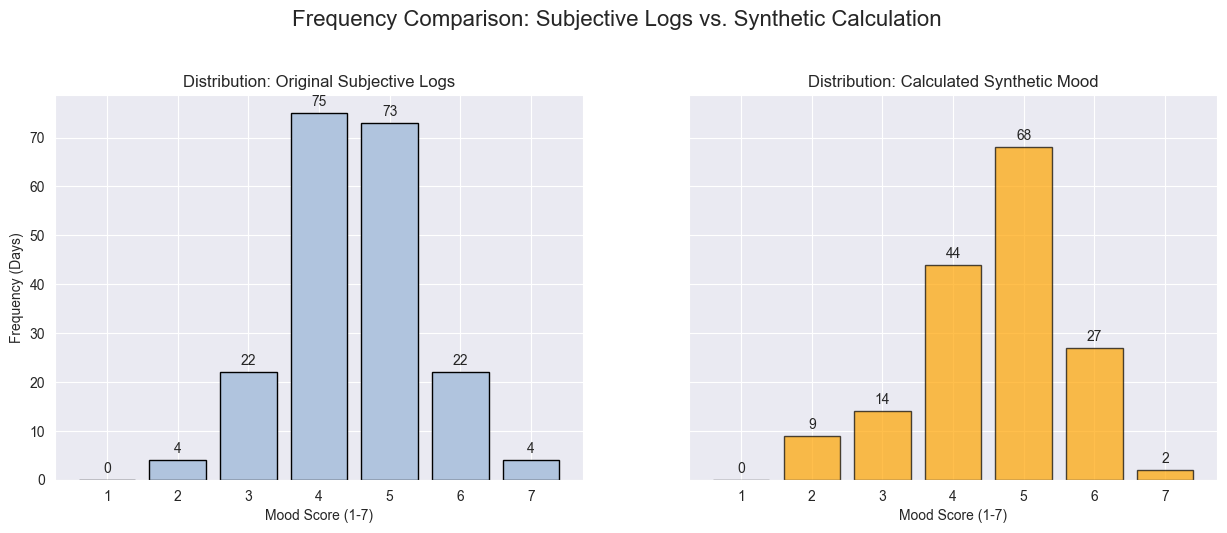

In [10]:
common_counts = df["common_mood_log"].value_counts().sort_index().reindex(range(1, 8), fill_value=0)
synthetic_counts = (
    df["total_mood"].round().value_counts().sort_index().reindex(range(1, 8), fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

bars1 = axes[0].bar(common_counts.index, common_counts, color="lightsteelblue", edgecolor="black")
axes[0].bar_label(bars1, padding=3)
axes[0].set_title("Distribution: Original Subjective Logs")
axes[0].set_xlabel("Mood Score (1-7)")
axes[0].set_ylabel("Frequency (Days)")

bars2 = axes[1].bar(
    synthetic_counts.index, synthetic_counts, color="orange", alpha=0.7, edgecolor="black"
)
axes[1].bar_label(bars2, padding=3)
axes[1].set_title("Distribution: Calculated Synthetic Mood")
axes[1].set_xlabel("Mood Score (1-7)")

plt.suptitle("Frequency Comparison: Subjective Logs vs. Synthetic Calculation", fontsize=16, y=1.05)
plt.show()

### 2.5. Frequency Comparison Analysis

The bar chart comparison visualizes what is hidden behind the mean values:
- Left Plot (Original Common Mood): Shows a near-normal distribution with a "psychological plateau" between scores 4 and 5. Score 4 acts as a "safe middle," the most frequent choice. Scores 2 and 7 are rare, indicating that extreme states are seldom recorded in subjective logs.
- Right Plot (Total Synthetic Mood): Exhibits a classic left-skewed distribution (negative asymmetry). We see a sharp frequency spike at score 5. Emotional markers "pull" the general background upward: what appeared as "neutral" (4) in logs actually corresponds to "good" (5) based on emotional composition.
- The "Unit One" Anomaly: A complete absence of score 1. This suggests that no critically destructive states occurred during the collection period, or the respondent subconsciously shifted the scale to a 2–7 range.

Visual Summary: The shift in peaks (4 vs. 5) is the key argument for splitting the target. The synthetic method doesn't just duplicate logs; it creates a new, more optimistic data profile.

### 2.6. Target Engineering: Statistical Summary & Conclusions
Due to the distinct statistical profiles, we decided not to merge these into a single target_mood at this stage. Instead, we maintain two separate target vectors for comparative analysis in future sections.

In [11]:
df = df.drop(columns=["target_mood"], errors="ignore")

df["target_common"] = df["common_mood_log"].astype(float)
df["target_common"] = df["target_common"].fillna(df["total_mood"])
df["target_synthetic"] = df["total_mood"].fillna(df["common_mood_log"])

In [12]:
comparison_final = (
    df[["common_mood_log", "total_mood", "target_common", "target_synthetic"]]
    .agg(["mean", "median", "std"])
    .round(2)
)
comparison_final.loc["cv_pct"] = (
    comparison_final.loc["std"] / comparison_final.loc["mean"] * 100
).round(2)
comparison_final.loc["mode"] = [
    df["common_mood_log"].mode()[0],
    df["target_common"].round().mode()[0],
    df["target_synthetic"].round().mode()[0],
    df["total_mood"].round().mode()[0],
]

display(comparison_final)

,common_mood_log,total_mood,target_common,target_synthetic
mean,4.50,4.57,4.41,4.51
median,4.00,4.64,4.27,4.64
std,0.97,1.02,1.00,0.97
cv_pct,21.56,22.32,22.68,21.51
mode,4.00,5.00,5.00,5.00


Key Findings:
1) Discrepancy in Modal Values: Direct logging (common_mood_log) has a mode of 4.0, while both synthetic metrics have a mode of 5.0. Subjectively, the respondent tends to rate the day as "average," but detailed emotion analysis reveals a higher actual emotional baseline.
2) Variability and Stability: All metrics show a Coefficient of Variation (CV) within the 21.5% – 22.7% range. This indicates moderate homogeneity: the data is not static (crucial for model training) but remains free of chaotic noise.
3) Amplitude Preservation (STD): The Standard Deviation (STD ≈ 1.0) remains practically unchanged across all strategies. This guarantees that none of the methodologies "compress" the data or distort the real picture of emotional fluctuations.
4) The STD Insight: The fact that target_synthetic STD (0.97) is nearly identical to common_mood_log is an excellent sign. It means that despite "reconstructing" data through emotions, we haven't introduced artificial noise. Our synthetic target is as "organic" and natural as the direct logs.

Final Verdict: Both generated features are statistically robust and suitable for use as target variables. The differences in their distributions will allow for a deeper comparison of influence factors in the next EDA stages.

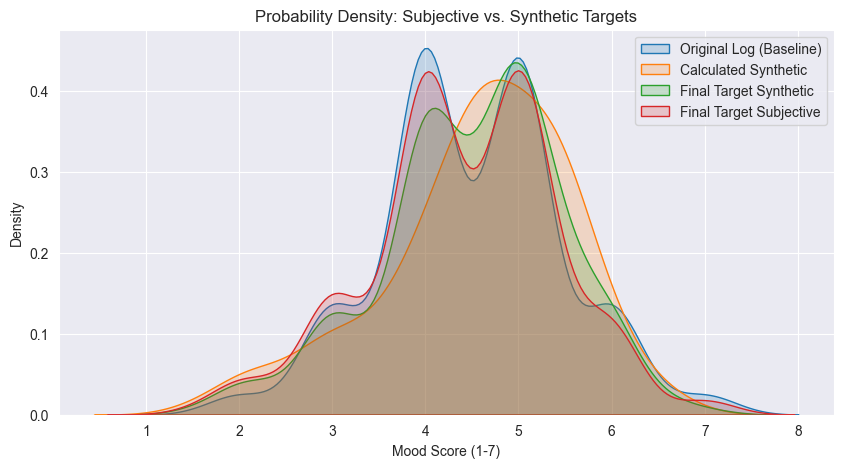

In [13]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.kdeplot(df["common_mood_log"], label="Original Log (Baseline)", fill=True, alpha=0.2)
sns.kdeplot(df["total_mood"], label="Calculated Synthetic", fill=True, alpha=0.2)
sns.kdeplot(df["target_synthetic"], label="Final Target Synthetic", fill=True, alpha=0.2)
sns.kdeplot(df["target_common"], label="Final Target Subjective", fill=True, alpha=0.2)
plt.title("Probability Density: Subjective vs. Synthetic Targets")
plt.xlabel("Mood Score (1-7)")
plt.ylabel("Density")
plt.legend()
plt.show()

### 2.7. Target Validation and Strategy Selection
Visual analysis of distributions (KDE Plot) and statistical metrics allows for the following conclusions regarding the quality of the target variables:
1. "Subjective vs. Objective" Thesis
    - Cognitive Bias: The plots clearly highlight a reporting bias. Original Log shows a pronounced peak at 4.0 (a psychological "safe harbor"), while Total Synthetic (based purely on decomposed emotions) shows a shifted peak at 5.0 (Left-skewed).
    - Insight: Emotional components capture positive states more frequently than the respondent is willing to admit when providing a direct, global assessment.
2. Gap-Filling Strategy Behavior
    - Common Target Synthetic (Red): Closest to the original data. It preserves the "bimodal" structure (peaks at 4 and 5) and remains more sensitive to negative states (higher density in the 2.5–3.5 range).
    - Target Synthetic (Green): Exhibits a smoother character. It successfully mitigates sharp jumps between 4 and 5, creating a continuous transition that is highly beneficial for the stability of regression model predictions.
3. ML Suitability
    - Representativeness: The absence of "1" values and the concentration of data in the 2–7 range provides a realistic picture of the respondent's life during this period.
    - Signal Quality: Sustained oscillation amplitude (STD ≈ 1.0) and a Coefficient of Variation (CV ≈ 22%) confirm that the synthetic data is not "flat" and contains sufficient signal for effective training.
4. The higher density of Common Target Synthetic in the lower bounds (2.5–3.5) suggests it might be a better target if the goal is to predict 'slumps' or burnout, whereas Target Synthetic is better for general trend forecasting.
5. The smoothing effect in the Target Synthetic (Green) acts as a natural regularizer, potentially reducing the impact of daily emotional 'outliers' on the model's learning process.

### Section Conclusions: Target Engineering & Validation Strategy
The stage of creating and validating target variables is complete. Based on the analysis, we have prepared the data for further modeling, accounting for the nuances of subjective logging.

#### 1. Statistical Validation and Signal Quality
* **Convergent Validity:** The correlation between direct logging and calculated synthetics is 0.74. This confirms that the synthetic metric is not random noise but accurately reflects the structure of the emotional state.
* **Metric Stability:** The Mean (approx. 4.5) and Standard Deviation (approx. 1.0) are nearly identical for both data types. This proves that emotion aggregation did not lead to data "compression" — we preserved the natural amplitude of mood fluctuations.
* **Variability:** The Coefficient of Variation (approx. 22.7%) indicates that the data has sufficient dynamics for training while remaining within statistical norms (without chaotic outliers).

#### 2. Divergence of Ratings: Cognitive Bias Hypothesis
Distribution analysis highlighted a critical feature of data collection:
* **Mode Shift (4.0 vs 5.0):** Direct logging has a peak at 4.0 (subjective "norm"), while the synthetic target peaks at 5.0.
* **Interpretation:** This observation allows us to hypothesize that full reliance on global subjective ratings may be suboptimal. The respondent may experience positive emotions throughout the day but tends to "round down" the state to a safe average level (4) during the final entry. Emotion decomposition provides a higher resolution of analysis, capturing nuances that are neutralized in general assessments.

#### 3. Technical Advantages of the Synthetic Target
* **Smoothing Effect:** Unlike "jagged" discrete logs, the synthetic target is a continuous value (float). This creates a smooth gradient for the model, improving the convergence of regression algorithms and acting as a natural regularizer.
* **Sensitivity to "Slumps":** The Common Target Synthetic indicator (Red) maintains a higher density in the lower score zone (2.5–3.5), making it a potentially better indicator for predicting phases of low energy or anxiety.

#### 4. Dataset Constraints
* **Range:** The complete absence of "1" values indicates that no critically destructive emotional crises occurred during the observation period. The model will be trained to operate within the "stable" range of 2–7.
* **Data Leakage:** It is confirmed that the target is built exclusively on internal emotional components. External predictors (sleep, steps, coffee) remain independent, guaranteeing the integrity of the upcoming experiment.

**Final Decision:** We will retain two target variables — target_common and target_synthetic. This will allow us to test whether external factors (predictors) can equally explain both the "conscious" self-assessment and the "hidden" emotional background.

## 3. Emotional Landscape Analysis: Anatomy of Mood
### 3.1. Emotional Equilibrium: Positive vs. Negative Drivers

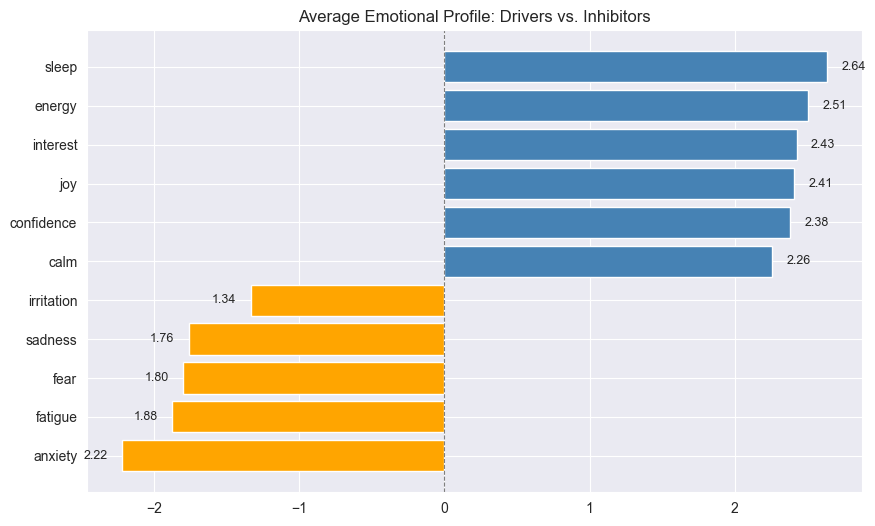

In [14]:
mood_log_mean = df[MOOD_COLUMNS].mean()

mask = mood_log_mean.index.isin(GOOD_MOOD_COLUMNS)
values = np.where(mask, mood_log_mean, -mood_log_mean)

order = np.argsort(values)
labels = mood_log_mean.index[order]
final_values = values[order]
colors = np.where(labels.isin(GOOD_MOOD_COLUMNS), "steelblue", "orange")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(labels, final_values, color=colors)

ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + (0.1 if width > 0 else -0.1),
        bar.get_y() + bar.get_height() / 2,
        f"{abs(width):.2f}",
        va="center",
        ha="left" if width > 0 else "right",
        fontsize=9,
    )

ax.set_title("Average Emotional Profile: Drivers vs. Inhibitors")
plt.show()

The analysis of the average values ​​of emotions allows us to determine the basic emotional profile of the respondent and understand which components have the greatest weight in the structure of the synthetic state indicator.
#### Key observations:
- **Structure of the positive background:** All positive markers (`sleep`, `energy`, `joy`, `confidence`) demonstrate high density and on average exceed the mark of 2.0. The sleep indicator has the highest average value (2.64), which makes it technically the strongest "positive driver" when calculating the synthetic target.
- **Resistance to acute negativity:** Most negative emotions (`irritation`, `sadness`, `fear`) remain in the range below 2.0 (closer to 1.0). This indicates that during the data collection period, the respondent rarely recorded states of acute upset or anger.
- **The phenomenon of background anxiety:** The highest average score among negative emotions is anxiety — 2.22. It significantly outperforms other negative markers and approaches the state of calm in terms of intensity. This suggests that increased anxiety is a typical background state for the respondent, rather than an episodic reaction.

#### Insights and hypotheses:
- **Irritation vs Anxiety divergence:** There is a noticeable significant gap between anxiety and irritability. Despite the high level of anxiety, the irritation score remains the lowest in the dataset (1.34). This indicates that the respondent's emotional stress is of the nature of "internal tension", rather than external aggression or reactivity.
- **Positive Synergy Hypothesis:** Since all positive emotions have almost the same average level, there is a high probability of their strong interdependence (multicollinearity).
- **Role of sleep:** Although we cannot at this stage state a causal relationship, sleep acts as the main "stabilizer" of the synthetic target, pulling its value up during periods of absence of other positive stimuli.

### 3.2. Contextual Emotion Patterns: Heatmap Analysis
Aggregation of average emotion values for each level of subjective assessment of the day. This allows you to see the emotional profile of each score.

In [15]:
mood_by_label = df.groupby("common_mood_log")[MOOD_COLUMNS].mean().astype(float)

Therefore, visualization of the distribution of emotion intensity through a heat map. This format clearly highlights anomalies and changes in mood structure when moving from low scores to high ones.

In [16]:
counts = df.groupby("common_mood_log")[MOOD_COLUMNS].apply(lambda x: x.notna().any(axis=1).sum())


def create_heat_map_ax(data, fig, ax, title):
    im = ax.imshow(data.values, cmap="viridis", aspect="auto")

    ax.grid(False)

    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=45, ha="right", rotation_mode="anchor")
    new_yticklabels = [f"Score {idx} (n={counts[idx]})" for idx in mood_by_label.index]
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(new_yticklabels)
    ax.set_title(title, pad=20)

    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            val = data.iloc[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="black", fontsize=12)

    fig.colorbar(im, ax=ax)

First, we visualize the absolute average values of emotions by mood assessment

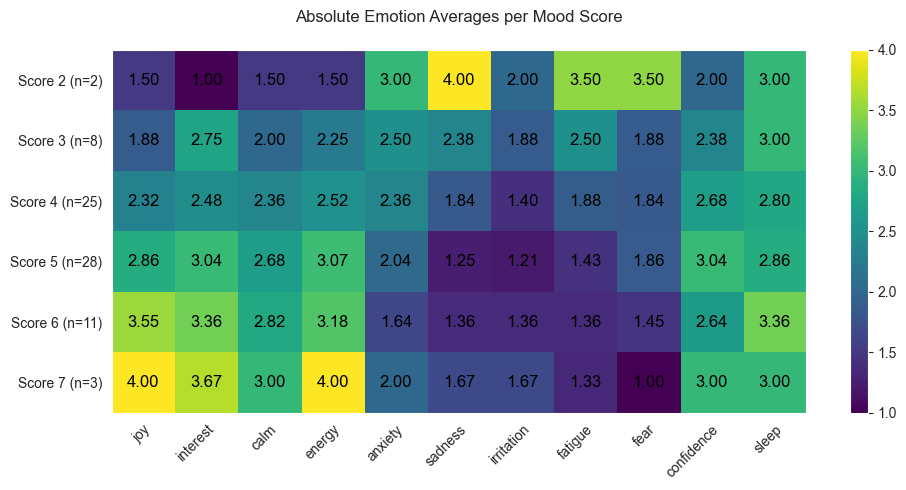

In [17]:
fig, axes = plt.subplots(figsize=(10, 5))

create_heat_map_ax(mood_by_label, fig, axes, "Absolute Emotion Averages per Mood Score")

plt.tight_layout()
plt.show()

Based on the analysis of heat maps and the distribution of average emotion values for each level of subjective mood (common_mood_log), the following comprehensive conclusion can be formulated:
1. Key drivers and inhibitors of mood
    - Linear drivers (Joy, Energy, Calm): There is a clear positive linear relationship between these emotions and the overall score. Joy (joy) demonstrates the most stable growth, becoming dominant already at level 3.0.
    - Background noise (Anxiety): Anxiety confirms the status of the “baseline background” — it remains high (2.36) even at a score of 4 (“norm”) and significantly decreases only when moving to a stably positive state (6+).
    - Stability of physiological indicators (Sleep): Sleep quality almost does not vary depending on the momentary mood. This indicates that sleep acts as an inert factor that does not change from the mood “today”, although in a longitudinal section it may be its cause.
2. Emotional thresholds and “tipping points”
    - The barrier between 4 and 5: This is the key point of transition to productivity. At a score of 5, there is a sharp “boost” of energy and interest, while the level of sadness drops to a minimum. This indicates that 5 is a state of active action, and 4 is only a passive absence of problems.
    - The nature of low scores (Score 3): Unlike high scores, where interest is the driver, state 3 is formed through the mechanisms of fatigue and anxiety. Interest is not manifested in this mood.
    - The paradox of confidence: The level of self-belief stabilizes much earlier than the general mood — it almost does not increase when moving from 5 to 6 points.
3. Asymmetries and borderline states
    - Asymmetry of Fatigue and Energy: These states are not mirror images. For example, at score 3, energy has already dropped to 2.25, but fatigue has not yet reached its maximum (2.50). This confirms that “low energy” and “high fatigue” are different biological processes.
    - Calm effect: At the peak (score 7), the level of calm is lower than joy and energy. This means that the ideal state for the respondent is a “drive”, energetic day, not a quiet rest.
    - Euphoric anxiety: At score 7, there is a slight increase in anxiety, which may be a marker of “positive arousal” or fear of losing control of the moment of euphoria.
    - Representativeness of edges: Scores 2 (n=2) and 7 (n=3) are currently statistical outliers. They indicate a vector (sadness dominates at score 2, joy and energy at 7), but require further data accumulation.

#### Preliminary hypotheses for building the ML model:
Based on the analysis, the following working hypotheses can be put forward for the modeling stage:
- Hypothesis about "Emotional weights": The model will have higher accuracy if it gives more weight to joy and energy as the main predictors of positive mood, and sadness as the main predictor of critical decline (score 2).
- Hypothesis about the nonlinearity of anxiety: Since anxiety is stable over a wide range (3-5), it may turn out to be a "bad" linear predictor for average values, but be a strong signal in combination with other features (interaction terms).
- Hypothesis about sleep inertia: The value of sleep for the current day will have a low correlation with the current mood, so it is advisable for the model to use a lagged feature (sleep for the previous night) as a predictor of the mood of the next day.
- 4/5 Differentiation Hypothesis: The difference between scores of 4 and 5 is best described by changes in interest and energy. A model using decision trees is likely to select these features for the first splits in this range.
- Linear Joy Hypothesis: joy is the most valid linear predictor of total score, showing the most predictable growth trajectory.

1) Linearity Check: This is a great idea. Build Regression Plots (sns.regplot) for each emotion against common_mood_log. This will allow you to mathematically calculate the coefficient of determination (R2) and say exactly: "Joy explains 85% of my mood, and Confidence only explains 15%.
2) Diff Table: As you said, create a table mood_by_label.diff(). This will show the "cost of transition" from one level to another. For example: "To go from 4 to 5, I need +0.5 to energy and −0.6 to sum".
3) Handle Outliers: Since the scores of 2 and 7 are few, try temporarily combining them with the neighboring ones (2 out of 3, 7 out of 6) in a new column mood_grouped to see if the trends change on a larger sample.

#### 3.2.2 Z-deviation analysis (Baseline Shift)

In [18]:
# Calculate the standard deviation for each emotion across the entire DF
mood_std = df[MOOD_COLUMNS].std()

# Calculate Z-score deviation
z_deviation = (mood_by_label - mood_log_mean) / mood_std


def classify_z(val):
    abs_val = abs(val)
    if abs_val > 2.0:
        return "Anomaly/Extremum"
    if abs_val > 1.0:
        return "Strong Signal"
    if abs_val > 0.5:
        return "Noticeable Signal"
    if abs_val > 0.2:
        return "Weak Signal"
    return "Noise"


interpretation_table = z_deviation.map(classify_z)
display(interpretation_table)

strong_signals = {}

for score in z_deviation.index:
    signals = z_deviation.loc[score]
    important = signals[signals.abs() > 1].sort_values(ascending=False)

    if not important.empty:
        formatted = [
            f"{emo} ({'▲' if val > 0 else '▼'}{abs(val):.2f})" for emo, val in important.items()
        ]
        strong_signals[f"Score {int(score)}"] = ", ".join(formatted)
    else:
        strong_signals[f"Score {int(score)}"] = "No strong signals (Baseline area)"

for score, desc in strong_signals.items():
    print(f"{score}: {desc}")

,joy,interest,calm,energy,anxiety,sadness,irritation,fatigue,fear,confidence,sleep
common_mood_log,,,,,,,,,,,
2,Strong Signal,Strong Signal,Strong Signal,Strong Signal,Strong Signal,Anomaly/Extremum,Strong Signal,Strong Signal,Anomaly/Extremum,Weak Signal,Weak Signal
3,Noticeable Signal,Weak Signal,Weak Signal,Weak Signal,Weak Signal,Noticeable Signal,Noticeable Signal,Noticeable Signal,Noise,Noise,Weak Signal
4,Noise,Noise,Noise,Noise,Weak Signal,Noise,Noise,Noise,Noise,Weak Signal,Noise
5,Noticeable Signal,Noticeable Signal,Noticeable Signal,Noticeable Signal,Weak Signal,Noticeable Signal,Noise,Weak Signal,Noise,Noticeable Signal,Weak Signal
6,Strong Signal,Strong Signal,Noticeable Signal,Noticeable Signal,Noticeable Signal,Weak Signal,Noise,Noticeable Signal,Weak Signal,Weak Signal,Noticeable Signal
7,Anomaly/Extremum,Strong Signal,Strong Signal,Strong Signal,Weak Signal,Noise,Noticeable Signal,Noticeable Signal,Noticeable Signal,Noticeable Signal,Weak Signal


Score 2: sadness (▲2.57), fear (▲2.07), fatigue (▲1.77), anxiety (▲1.24), irritation (▲1.09), calm (▼1.14), joy (▼1.15), energy (▼1.24), interest (▼1.64)
Score 3: No strong signals (Baseline area)
Score 4: No strong signals (Baseline area)
Score 5: No strong signals (Baseline area)
Score 6: joy (▲1.44), interest (▲1.07)
Score 7: joy (▲2.02), energy (▲1.84), interest (▲1.42), calm (▲1.13)


Z-deviation (Baseline Shift) analysis allows you to mathematically confirm the strength of the emotional signal and separate real drivers from statistical noise.
1. Mathematical confirmation of emotional homeostasis (Plateau 3-4-5)
    - Score 4 — “Absolute zero”: The Z-score for almost all columns is in the Noise zone (<∣0.2∣). This mathematically proves that score 4 is your “default” state. No emotion here acts as a driver — it is a pure base.
    - Score 3 and 5 — “Weak signal zone”: These scores do not have any Strong Signal (>1.0). This confirms the hypothesis that the transition 4 → 5 occurs not due to a radical change in state, but due to the accumulation of small positive shifts (Interest, Confidence, Energy), which barely cross the threshold of perceptibility.
2. Extreme states as “Emotional anomalies”
    - Score 2: Emotional catastrophe. We see two values in the Anomaly/Extremum zone (>2.0): sadness (▲2.57) and fear (▲2.07). This confirms that “two” is not just a “bad mood”, but a critical system failure, where negative emotions go beyond 2.5 standard deviations.
    - Score 7: Pure euphoria. joy (▲2.02) crosses the anomaly threshold. This confirms that state 7 is a qualitatively different level of joy compared to even the “six” (where Joy is only ▲1.44).
3. Verification of the ML hypothesis
    - Confirmed (Joy Hypothesis): Joy is the only emotion that goes from Strong Negative (-1.15) through Noise to Anomaly (2.02). This confirms its role as the main linear predictor.
    - Confirmed (Anxiety Hypothesis): At the 3-4-5 plateau, anxiety has the status of Weak Signal/Noise. Its influence becomes noticeable (Strong Signal) only at a score of 2. This means that for the model, anxiety will be useful only for detecting "crisis" states.
    - Refuted/Clarified (4/5 Hypothesis): We thought there was an "explosion" of interest there, but the Z-score shows only a Noticeable Signal (0.70). This means that the difference between 4 and 5 is very subtle, and the model will have difficulty distinguishing between them without additional data.
4. Remarks on representativeness: Strong signals at the edges of the spectrum (Score 2, 7) are based on a small sample (n=2,n=3), which increases the risk of statistical error. For the ML model, this means the need to apply regularization methods to prevent these "outliers" from excessively influencing the overall classification logic.

### 3.3. Emotional Variability Analysis and Signal Stabilization (STD)

In [19]:
display(mood_by_label.std().sort_values(ascending=False))

sadness       1.020187
joy           0.968789
interest      0.940949
energy        0.862275
fatigue       0.859108
fear          0.845200
calm          0.562808
anxiety       0.473687
confidence    0.391281
irritation    0.311010
sleep         0.196249
dtype: float64

#### Primary STD Analysis

The initial calculation of all scores showed that Sadness (1.02) and Joy (0.96) had the greatest variability. This confirmed the hypothesis that these emotions are the main markers of differences between days. However, due to the small number of records at the edges (Score 2 and 7), there was a risk of statistical distortion.

In [20]:
df["mood_grouped"] = df["common_mood_log"].replace({2: 3, 7: 6})

#### Stabilization through Binning

To obtain a more accurate “clean” signal, it was decided to combine the extreme states: 2 → 3 (Critical Low) and 7 → 6 (Euphoric). This allowed us to eliminate random emissions and focus on stable emotional patterns.

In [21]:
grouped_std = df.groupby("mood_grouped")[MOOD_COLUMNS].mean()
display(grouped_std.std().sort_values(ascending=False))

joy           0.787395
sadness       0.646006
fatigue       0.617418
energy        0.561768
interest       0.48575
calm          0.419764
anxiety       0.385782
fear          0.346531
confidence    0.301155
irritation    0.292072
sleep         0.216967
dtype: Float64

Results after stabilization

After recalculating the average values by group, we got the final rating of emotions by their ability to differentiate the state:
### Results after stabilization

After regrouping and recalculating the average values, we got the final rating of emotions by their ability to differentiate the state. The higher the STD indicator in this table, the more "information gain" this feature of the model will give.

| Emotion | Variability (STD) | Role in Modeling |
| :--- | :--- | :--- |
| **Joy** | **0.787** | **Main Driver:** The strongest linear signal for class separation. |
| **Sadness** | **0.646** | **Key Marker:** Primary indicator of transition into negative (Low) states. |
| **Fatigue** | **0.617** | **Physical Predictor:** Clearly distinguishes workdays from exhaustion days. |
| **Energy** | **0.561** | **Resource Metric:** Critical for differentiating between Score 4 and 5. |
| **Interest** | **0.485** | **Cognitive Marker:** Engagement signal that increases at high scores. |
| **Calm** | **0.419** | **Background State:** Moderately correlates with the overall daily calmness. |
| **Anxiety** | **0.385** | **Weakly Linear Signal:** Present almost always (background noise). |
| **Fear** | **0.346** | **Specific Signal:** Manifests only at critical crisis points. |
| **Confidence** | **0.301** | **Stable Feature:** Shows little change during mood fluctuations. |
| **Irritation** | **0.292** | **"Noise":** Too low variability for effective model training. |
| **Sleep** | **0.216** | **Inert Feature:** Nearly constant; low priority for immediate prediction. |

#### **Final conclusion for the modeling stage:**

1. **Feature hierarchy:** The model will have the highest accuracy if it uses `joy`, `sadness`, `fatigue` and `energy` as primary features for building a "decision tree". They are most sensitive to changes in the target variable.
2. **Noise cutoff:** Parameters such as `sleep` and `irritation` have minimal variance. For the model, these features will have a low weight, so they can be used as auxiliary or excluded altogether to simplify the architecture, but these are conclusions on specific days, in time they may be more important.
3. **Grouping efficiency:** The strategy of combining extremes (2+3 and 6+7) proved to be effective, confirming that `joy` (0.78) is the most powerful signal for detecting positivity, and the variability of `sadness` (0.64) is the most reliable way to identify a drop in mood.

### 3.4. Dynamics of Emotional Transitions: The "Price" of Moving Between 3, 4, 5, and 6

Since scores **3, 4, 5, and 6** make up the bulk of the dataset ("working range"), it is critical to understand what micro-changes in emotion cause a respondent to make one rating or another. This is an investigation of the "delta" (difference) between adjacent levels.

In [22]:
import pandas as pd

transitions = pd.DataFrame(
    {
        "3 -> 4 (Recovery)": mood_by_label.loc[4] - mood_by_label.loc[3],
        "4 -> 5 (Activation)": mood_by_label.loc[5] - mood_by_label.loc[4],
        "5 -> 6 (High Flow)": mood_by_label.loc[6] - mood_by_label.loc[5],
    }
)


def print_transition_insights(df):
    for col in df.columns:
        print(f"\n--- {col} ---")
        top_inc = df[col].sort_values(ascending=False).head(3)
        top_dec = df[col].sort_values(ascending=True).head(3)

        print("📈 GROWTH: " + ", ".join([f"{idx} (+{val:.2f})" for idx, val in top_inc.items()]))
        print(
            "📉 DECLINE:      " + ", ".join([f"{idx} ({val:.2f})" for idx, val in top_dec.items()])
        )


print_transition_insights(transitions)


--- 3 -> 4 (Recovery) ---
📈 GROWTH: joy (+0.44), calm (+0.36), confidence (+0.31)
📉 DECLINE:      fatigue (-0.62), sadness (-0.53), irritation (-0.48)

--- 4 -> 5 (Activation) ---
📈 GROWTH: interest (+0.56), energy (+0.55), joy (+0.54)
📉 DECLINE:      sadness (-0.59), fatigue (-0.45), anxiety (-0.32)

--- 5 -> 6 (High Flow) ---
📈 GROWTH: joy (+0.69), sleep (+0.51), interest (+0.33)
📉 DECLINE:      fear (-0.40), confidence (-0.40), anxiety (-0.40)


#### Thought process and analysis of the “steps”:
1) Transition 3 → 4 (Recovery):
    - Observation: Fatigue and sadness are most noticeably “striking”.
    - Logic: The rise from “three” to “norm” is primarily a process of getting rid of negative ballast. In order for the respondent to put 4, he needs not so much to feel joy, but to “drop” the burden of fatigue (-0.62) and sadness (-0.54).
2) Transition 4 → 5 (Activation):
    - Observation: Interest, energy and sadness dominate.
    - Logic: This is a transition from passive “everything is ok” (4) to active “I am in the resource” (5). A triad of drivers is involved here: the respondent feels more curiosity (+0.56) and energy (+0.55), which finally displaces the remnants of sadness (-0.59).
3) Transition 5 → 6 (High Flow):
    - Observation: The main indicator is happiness (joy), as well as sleep and anxiety.
    - Logic: At this level, productivity (interest/energy) is already stabilizing, and pure emotions come to the fore. Joy increases sharply (+0.69), and anxiety decreases (-0.40). An interesting connection with sleep (+0.51) - the feeling of a score of 6 often correlates with physical recovery.

#### Conclusions for future modeling:
* Class differentiation: The model should not look for "joy" to distinguish 3 from 4 - it should look for "absence of fatigue". Instead, to separate 5 and 6, it is `joy` that will become the decisive factor.
* Specificity of the "five": Score 5 is a unique point where `interest` has maximum predictive power. This is the "fuel" that distinguishes a working state from just a calm day.
* Feature Engineering: It is possible to create a synthetic feature "Negativity Release" (`fatigue + sadness`) specifically for identifying lower thresholds (3-4).

### 3.5. Analysis of overall emotional intensity (Intensity)

The `emotion_intensity` parameter is calculated as the arithmetic mean of all emotional markers. This metric reflects the overall "energy background" of the day without being tied to a specific sign (positive/negative).

In [23]:
df["emotion_intensity"] = df[MOOD_COLUMNS].mean(axis=1)

common_mood_log
2    2.409091
3    2.306818
4    2.225455
5    2.301948
6    2.371901
7    2.575758
Name: emotion_intensity, dtype: Float64

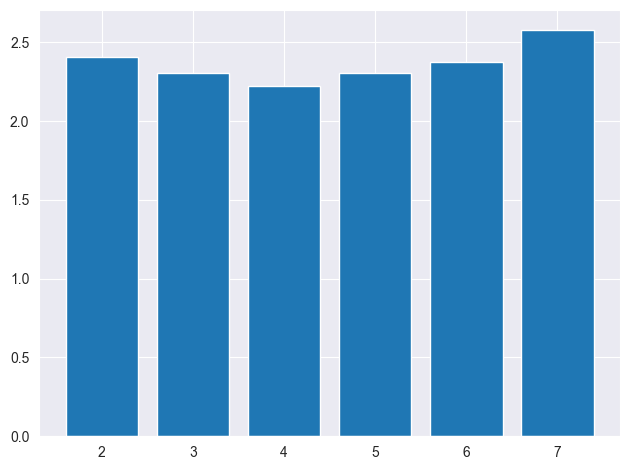

In [24]:
common_emotion_intensity = df.groupby("common_mood_log")["emotion_intensity"].mean()
display(common_emotion_intensity)

fig, ax = plt.subplots()
ax.bar(common_emotion_intensity.index, common_emotion_intensity)

plt.tight_layout()
plt.show()

Key observations:
* U-shaped trend: The graph shows that the intensity increases at the poles (scores 2 and 7) and subsides at the "calm point" at score 4.
* Weak signal: The difference between the minimum (2.22) and the maximum (2.57) is only ~15%. This is a fairly narrow range that could be statistical noise.
* Low representativeness: Due to the small number of records at the edges (scores 2 and 7), the high intensity values ​​at these points may be random outliers rather than a stable pattern.

Conclusion for the model:
Most likely, this is a weak signal. It is not advisable to use this parameter as a main predictor. It can only be useful as an auxiliary nonlinear feature to separate "calm" days (4) from "active" days (all others), but you should not expect a significant increase in accuracy from it.

### 3.6. Emotional Volatility Analysis (Emotional Std)
This section examines the "dispersion" (STD) of emotions within a day: how stable or chaotic the emotional state is depending on the final score for the day.

In [25]:
df["emotion_variability"] = df[MOOD_COLUMNS].std(axis=1)

In [26]:
common_emotion_variability = df.groupby("common_mood_log")["emotion_variability"].mean()
display(common_emotion_variability)

common_mood_log
2    1.158636
3    0.795415
4     0.75147
5    0.942911
6      1.0684
7    1.205998
Name: emotion_variability, dtype: Float64

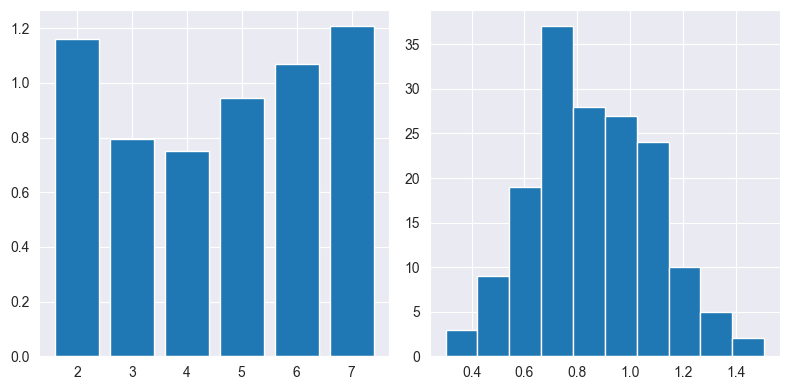

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].bar(common_emotion_variability.index, common_emotion_variability)
ax[1].hist(df["emotion_variability"])

plt.tight_layout()
plt.show()

**Key observations:**
* **Stability plateau (3-4):** STD at scores 3 and 4 are almost the same. This confirms that in this range the emotional background is as flat as possible ("calm"), and there is enough data here to draw a confident conclusion.
* **Increasing trend (5-6):** Starting from 5, we see a clear tendency for the spread to increase. This means that the higher the mood, the more "amplitude" emotions (for example, sharp bursts of Joy) are involved.
* **Peak at the poles (2 and 7):** Although the values ​​are few, they continue the general trend: at 7, volatility is highest. Even taking into account the small data, this looks like a logical conclusion of the trend that began at 5.
* **STD distribution (Right-Skewed):** The distribution graph of the total STD has a right-sided asymmetry. This means that most of your days are emotionally stable (low STD), and days with high volatility ("swings") are exceptions.

**Model implications:**
1. **"Calm" zone:** The model will have a hard time distinguishing 3 and 4 purely on the STD score, because they are identical in volatility. Other predictors are needed here.
2. **Growth signal:** The STD score can be a good marker for separating "resource" states (5, 6, 7) from "base" ones (3, 4).
3. **Asymmetry handling:** Since the STD distribution is **Right-Skewed**, for linear models it is worth considering logarithmizing this feature to reduce the impact of "swing" days-outliers.

### 3.7. Distribution of Aggregated Emotions (Positive vs Negative)
In this section, we compare the nature of positive and negative emotional states through their aggregate distributions.

In [28]:
df["pos"] = df[GOOD_MOOD_COLUMNS].mean(axis=1)
df["neg"] = df[BAD_MOOD_COLUMNS].mean(axis=1)

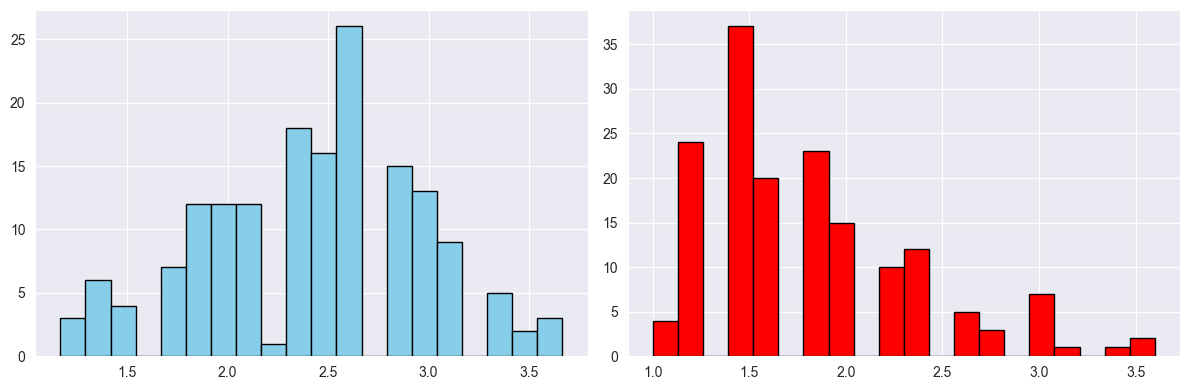

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df["pos"], bins=20, color="skyblue", edgecolor="black")
ax[1].hist(df["neg"], bins=20, color="red", edgecolor="black")

plt.tight_layout()
plt.show()

#### **Graph 1: Distribution of positive emotions**
* **Fact:** The distribution is close to normal (bell-shaped), with a center shift in the region of 2.5–3.0.
* **Insight:** This indicates the presence of a constant "baseline" of positivity on most days; the respondent is rarely in absolute euphoria or in a complete emotional vacuum.
* **Action for the model:** This feature is "pure" and stable; standard scaling (`StandardScaler`) is sufficient for it.

#### **Graph 2: Distribution of negative emotions**
* **Fact:** There is a strong **Right-Skewed** distribution (positive asymmetry) with a long "tail" on the right.
* **Insight:** Most days of the respondent have a low level of negativity, and high levels of sadness or anxiety are rare outliers (anomalies).
* **Model Action:** Since the data is very skewed, linear models will struggle to handle it. It is worth applying logarithmization (`np.log1p`) or using decision trees, which are better at handling such skewness.

**Summary Model Conclusions:**
1. **Positive as Background:** Total positivity is a reliable marker for determining the "normality" of a day.
2. **Negative as Trigger:** High values of negative emotions (the same tail) carry a lot of weight - for the model, this should be a signal of an "extreme day", even if there are few such values.
3. **Asymmetry:** Due to the different nature of the distributions (normal vs. skewed), the model will benefit more if we process positive and negative features with different transformation methods.

### 3.8. Emotional Balance Analysis (Pos-Neg Balance)
The `balance` metric is calculated as the difference between the total positive and negative. It shows the ``net balance'' of the emotional state for the day.

In [30]:
df["balance"] = df["pos"] - df["neg"]

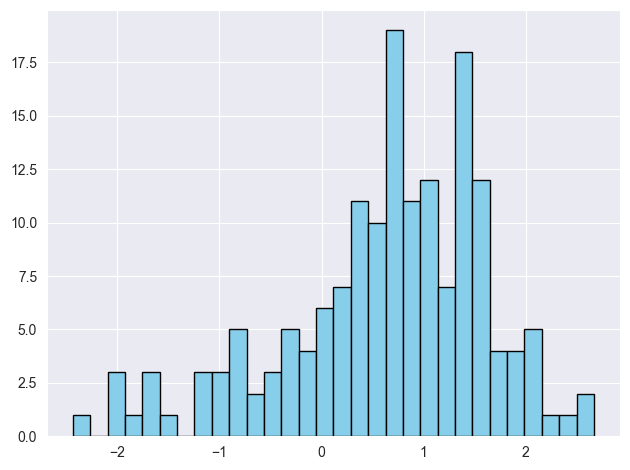

In [31]:
fig, ax = plt.subplots()
ax.hist(df["balance"], bins=30, color="skyblue", edgecolor="black")

plt.tight_layout()
plt.show()

**Key observations:**
* **Positive Bias:** The center of the distribution is in the positive field (above 0). This statistically confirms that most days the respondent is dominated by positive emotions.
* **Asymmetry of descents:**
    * **Left tail (Negative):** It descends very smoothly. This means that the transition to a deep "minus" occurs gradually and has many intermediate states. A smooth left descent means that the respondent's "bad" days are very different in structure (somewhere more anxiety, somewhere fatigue). This is difficult for the model, because there is no single "minus day" pattern.
    * **Right tail (Positive):** It breaks off sharply. This indicates the presence of a certain "glass ceiling" of positivity - above a certain level of joy, which usually does not jump. A sharp right cliff speaks of a "resource ceiling". This is ideal for the model: once the balance crosses a certain threshold, we have a 90% chance of getting a Score of 6 or 7.
* **Zone 0-1:** Zone 0-1 is the emotional homeostasis zone. The huge peak here means that the system (organism) tends to return to a neutral state (Score 4) even after small fluctuations.
* **Zone 1-2** (Second Echelon): The second largest peak. It corresponds to "above average" days (Score 5). This indicates that the positive state has two stable equilibrium points: "just ok" (0-1) and "productive" (1-2)

**Verdict:** This is the **most important synthetic feature**. It works as a "low-pass filter", cutting out daily noise and leaving a clean mood trend.
**Conclusions for the model:**
1. **Informativeness:** This is one of the strongest features. It aggregates the two vectors into one clean signal.
2. **Anomaly Detection:** Since the right edge is cut off abruptly, any deviation beyond this "standard maximum" will be a clear signal to the model with a score of **7**.
3. **Linearity:** Unlike individual negative emotions, `balance` has a more symmetrical appearance, making it ideal for linear models and neural networks without complex pre-training. This is critical for linear regression, as it does not see the relationships between the individual `pos` and `neg` columns well.
4. **Dimensionality Reduction:** Instead of forcing the model to calculate the difference between `joy` and `sadness` itself, we give it a ready-made vector. This reduces the risk of overfitting, especially on small data.
5. **Detection of "pure" signal:** If `joy=5` and `sadness=4`, the total intensity is high, but the balance is low (1). This helps the model understand that the day was emotionally rich, but as a result "nothing" (Score 4). Without this feature, the model could mistakenly give a high score due to a high `joy` indicator.
6. **The model will easily distinguish a "bad" day from a "good" one**: there is a clear "valley" (zone near zero) between them. But it will be harder for it to distinguish "just ok" and "super ok", because these peaks are very close.

### 3.9. Detailed analysis of the distribution of emotional markers
This section examines the internal structure of each emotion: how often they appear and with what intensity (on a scale from 1 to 4).

In [32]:
mood_intensity_frequencies = (
    df[MOOD_COLUMNS].melt().groupby("variable")["value"].value_counts().reset_index()
)
mood_frequency_table = mood_intensity_frequencies.pivot(
    index="variable", columns="value", values="count"
)
display(mood_frequency_table)

value,1,2,3,4
variable,,,,
anxiety,14,104,42,4
calm,15,97,47,5
confidence,25,67,56,16
energy,17,63,68,16
fatigue,69,57,27,11
fear,69,65,24,6
interest,26,58,64,16
irritation,120,34,9,1
joy,18,74,59,13


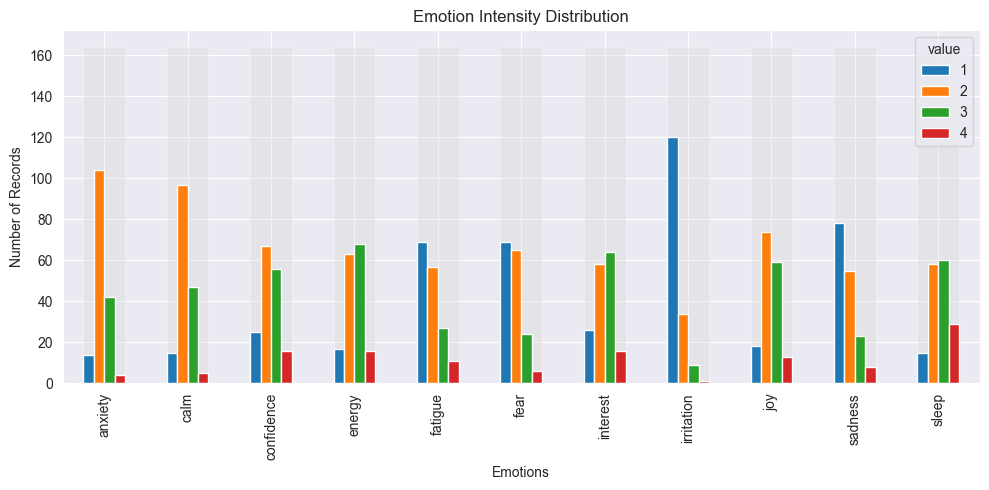

In [33]:
total_counts_per_mood = df[MOOD_COLUMNS].melt().groupby("variable")["value"].count()
ax = total_counts_per_mood.plot(
    kind="bar", stacked=True, figsize=(10, 5), width=0.5, alpha=0.3, color="lightgrey"
)
mood_frequency_table.plot(kind="bar", ax=ax)

plt.title("Emotion Intensity Distribution")
plt.xlabel("Emotions")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

#### **Key observations:**

1. **Positive Skew emotions:**
    * **Group:** `anxiety`, `calm`, `confidence`, `joy`.
    * **Insight:** Most of the values are concentrated in the left part (low intensity).
    * **Feature of `anxiety`:** Although it is a negative emotion, it behaves like a positive one (according to the distribution structure). This may mean that the user's anxiety is constantly present as background noise, but rarely reaches critical values.

2. **Negative Skew emotions:**
    * **Group:** `sleep`.
    * **Insight:** Sleep is the only metric where high values (3-4) occur more often than low ones. This indicates a generally healthy regimen or a priority for rest.

3. **Normal Distribution:**
    * **Group:** `energy`, `interest`.
    * **Insight:** These states are the most balanced. They are the "engine" of the day and have an equal probability of being both high and low.

4. **Exponential Decay:**
    * **Group:** `fatigue`, `fear`, `irritation`, `sadness`.
    * **Insight:** These emotions are "heavy" in nature. Their intensity decreases almost exponentially. They probably require a large amount of energy from the body, so the psyche cannot maintain them at a high level (3-4) for a long time. I would like to check if they go together and how they go over time

#### **Model implications:**

* **Negative clustering:** Since `fatigue`, `fear`, `irritation` and `sadness` have identical distributions, they are likely to be highly correlated. For the model, this means a risk of **multicollinearity**. It might be worth combining them into a single "Negative Stress Index" to stabilize the learning.
* **`anxiety` as a unique predictor:** Because anxiety stands out from the general pattern of negative emotions, it can be a "leading indicator" - its rise can signal a future drop in the overall mood score before other emotions.
* **Emotion predictability:** Emotions with exponential decay (e.g. `irritation`) are excellent markers for detecting abnormally bad days (Score 2). Even a small value (2 or 3) in these columns should be a strong argument for the model to lower the overall prediction.
* **Rare Events Analysis:** High values of emotions with "exponential decay" (fear=4, irritation=4) are extremely rare (<5% of cases). For the model, these are "strong signals". Even one such unit in the data can outweigh ten units of joy. It is worth checking whether these rare cases are not key predictors for the lowest scores (Score 2).
* **Resistance to "positive noise":** Since `joy` and `confidence` have a large percentage of values of 2 and 3, the model may start to ignore them, considering them as "normal background". It will be necessary to test the creation of a binary feature: "Is there at least one negative emotion > 2?", which may be more effective than 10 separate columns.

### 3.10. Analysis of the shape of distributions (Kurtosis)
The coefficient of kurtosis allows us to assess how concentrated the data is around the mean and how "heavy" the tails of the distribution are.

In [34]:
moods_kurt = df[MOOD_COLUMNS].kurtosis().sort_values()
display(moods_kurt)

sleep         -0.74016
interest     -0.700465
confidence    -0.61821
energy       -0.465777
joy          -0.378491
fatigue      -0.313989
fear         -0.014713
sadness       0.049544
calm          0.222339
anxiety       0.524663
irritation    2.832071
dtype: Float64

#### **Key observations:**

1. **Sniper effect (`irritation` ≈ 2.83):**
    * **Insight:** Highest positive kurtosis. The data is maximally concentrated around a single value (score 1).
    * **Character:** This is a classic **Sparse feature**. It is "silent" most of the time, but its activation (value > 1) is a powerful single signal.

2. **Emotional plateau zone (`sleep`, `interest`, `confidence` < -0.6):**
    * **Insight:** Lowest kurtosis (platykurtoid distribution). The data is "smeared", has high variability and no pronounced dominant state.
    * **For Energy/Interest:** The distribution is symmetric, but has negative kurtosis, indicating high variability and no single dominant state.
    * **For Sleep:** The indicator -0.74 indicates the greatest "flatness". This means high variability of the data, which gives many examples for comparing different sleep states ("what happens when sleep 1", "sleep 2" and so on).

3. **Similarity of nature (`fatigue`, `fear`, `sadness` ≈ -0.3 to 0.05):**
    * **Insight:** The indicators are very close to each other and to the normal distribution (mesokurtoid).
    * **Character:** There is a monotonic decline, which in terms of kurtosis corresponds to the tails of the normal distribution.

4. **Paradox of `calm` and `anxiety`:**
    * **Insight:** Both features have positive kurtosis (are "on the same side of the barricades").
    * **Domain conclusion:** This may indicate their common nature (the calm/anxiety spectrum) or that they are two extremes of the same feature that equally tend towards stable values.

#### **Model conclusions:**
* **Binarization of `irritation`:** Due to the high concentration at one point, it may be more efficient for models (especially linear ones) to convert this feature to binary: `0` (no irritation) and `1` (any value > 1). This will remove unnecessary noise.
* **Double-edged sword of `sleep`:** High flatness (low kurtosis) is both good and bad. On the one hand, we have a lot of data to compare. On the other hand, the lack of a model dominant can make it harder to clearly predict a specific value, because they are almost evenly distributed.
* **`anxiety` as a background process:** Kurtosis 0.52 confirms that anxiety is a stable "background" process with a pronounced peak. For the model, this means that a change in anxiety even by +1 point will be critically significant, because it "breaks out" of its very narrow distribution.
* **Feature Grouping:** The `fatigue/fear/sadness` group, due to the similarity of the shape of the distributions and the kurtosis values, confirms the hypothesis that they can be combined into one latent factor of "general depression".
* **Ideal state for training (`energy/interest`):** A symmetric distribution with negative kurtosis provides a wide palette of states for training the model without a pronounced skew at one point.

### 3.11. Analysis of Variance and Stability of States
The variance allows us to determine how much each emotion deviates from its average value. This directly indicates the "dynamicity" of the indicator: whether it is a stable background or an active marker of change.

In [35]:
moods_var = df[MOOD_COLUMNS].var().sort_values()
display(moods_var)

irritation    0.371502
anxiety       0.393237
calm          0.437079
joy           0.623485
energy        0.656404
fear          0.677054
confidence    0.741097
sadness       0.759053
interest      0.761484
sleep          0.77958
fatigue       0.843932
dtype: Float64

#### **Key Observations:**

1. **Emotional Anchors (`irritation`, `anxiety`, `calm` < 0.45):**
    * **Insight:** These three states have the lowest variability. They form a stable baseline plateau.
    * **Domain Conclusion:** The respondent is either ``almost always calm'' or ``stablely anxious'', and irritation occurs extremely rarely. These traits have a low ``specific weight'' for daily fluctuations, but act as a safety net for the system.

2. **Dynamic Leader (`fatigue` ≈ 0.84):**
    * **Insight:** Fatigue is the most unstable state. It changes the most strongly among all emotions.
    * **Conclusion:** Unlike stable anxiety, fatigue is not background noise, but a very sensitive and dynamic indicator that reacts sharply to the events of the day.

3. **Depression group breakdown:**
    * **Insight:** While `fatigue`, `fear` and `sadness` seemed to be homogeneous in terms of kurtosis, the analysis of variance shows a gap: `fatigue` (0.84) is much more dynamic than `fear` (0.67).
    * **Conclusion:** These states have a similar distribution shape, but different amplitudes of oscillations.

4. **High variability of sleep and interest (> 0.75):**
    * **Insight:** The indicators `sleep`, `interest` and `sadness` have high variance.
    * **Conclusion:** This confirms the "flatness" of their distributions (low kurtosis). There are many contrasts in the data, which is useful for training the model.

#### **Conclusions for the model:**

* **Importance of `fatigue` as a predictor:** Due to its high variance, fatigue can be the main "driver" of the change in the overall Score. The model should pay high attention to this feature (High Feature Importance).
* **Weakness of the linear relationship with `irritation`:** It will be extremely difficult for the model to guess a change in mood based on irritation alone, since it hardly changes. This confirms the feasibility of binarizing this feature, which we discussed earlier.
* **Stability of `calm/anxiety`:** Since these features have similar low variability, they can act as a "baseline" for the model. Any deviation from their consistently low level of variance will signal to the model that the context of the day has changed radically.
* **Prioritizing dynamic features:** For neural networks and Gradient Boosting, it is worth paying attention to features with variance > 0.5 (joy, energy, sleep). They form the "body" of the prediction, while low-variance features (irritation) work as specific triggers.

### 3.12. Analysis of distribution skewness (Skewness)
Skewness (the coefficient of asymmetry) shows in which direction the distribution is "skewed". This helps to understand which values (low or high) each emotion tends to reach in everyday life.

In [36]:
moods_skewc = df[MOOD_COLUMNS].skew().sort_values()
display(moods_skewc)

energy       -0.054973
interest     -0.053177
sleep        -0.036915
confidence    0.102118
joy           0.116834
calm           0.31185
anxiety       0.404356
fatigue       0.774047
fear          0.791032
sadness       0.934198
irritation    1.807251
dtype: Float64

#### **Key observations:**

1. **Negative triad (`fatigue`, `fear`, `sadness` ≈ 0.7–0.9):**
    * **Insight:** High positive Skewness confirms that these emotions always "push" towards unity (minimum).
    * **Mathematical law:** Although the "law of decline" is similar for them (kurtosis ≈ 0), different variance indicates different nature of stability.
    * **Assumption:** Fatigue (`fatigue`) "releases" much more slowly and is more often high than fear or sadness. Fatigue is the foundation (background) on which more acute negative states arise.

2. **Irritation anomaly (`irritation` ≈ 1.81):**
    * **Insight:** Extreme leftward skew. This once again confirms the hypothesis that it is appropriate to convert this feature to a Boolean value (0/1), since it is statistically isolated from other emotions.

3. **Symmetry of "Motors of the Day" (`energy`, `interest`, `sleep` ≈ -0.05):**
    * **Insight:** Skewness is close to zero. This means that the distribution is symmetric, similar to a "mountain" in the middle.
    * **Conclusion:** These values do not have a strong tendency to extremes, which makes them the most balanced predictors for the model.

4. **Moderate positive skew (`joy`, `confidence` ≈ 0.1):**
    * **Insight:** They are concentrated around values 1-2, but have a slight skew, which distinguishes them from the perfectly symmetric `energy/interest`.

5. **The `calm` - `anxiety` relationship (0.31 and 0.40):**
    * **Insight:** Both features have a similar slope, which once again confirms their common nature or work in a single emotional circuit.

#### **Conclusions for the model:**

* **The need for scaling (Standardization):** Since different emotions have different Skewness and dispersion, the use of `StandardScaler` or `RobustScaler` is critical. Without this, the model may erroneously give more weight to "symmetrical" features, ignoring "sharp" signals like irritation.
* **Fatigue as a "Baseline":** The model should test the hypothesis: is high fatigue a prerequisite (context) for the appearance of high values ​​of fear or sadness.
* **Scale Variability:** Different variance with similar kurtosis suggests that the 1-4 scale is subjectively perceived differently for negative emotions than for positive ones. The model should take this "sensitivity" into account through weighting factors.
* **Linearity Problem:** Due to the high Skewness (>0.7) in the negative group, a simple linear regression can give a large error. It is worth testing Log Transformation for these columns or using nonlinear models (Random Forest/XGBoost).
* **Joy/Confidence Synchrony:** Almost identical Skewness indicates that these states occur in parallel. These are potential candidates for merging if the model starts to overfit on a large number of features.
* **Feature Scaling Sensitivity:** The step between 1 and 2 for `irritation` (high skew) and `sleep` (low skew) has different mathematical weight. The model must be sensitive to the fact that for rare emotions, even a minimal increase is a radical signal.

### 3.13. Heatmap of Relative Intensity Distribution (%)
This visualization normalizes the data, showing the "density profile" of each emotion. This allows you to compare emotion patterns regardless of the total number of entries, revealing hidden patterns in the scores.

In [37]:
intensity_distribution_pct = (mood_frequency_table * 100).divide(total_counts_per_mood, axis=0)
intensity_distribution_pct = intensity_distribution_pct.astype(float)

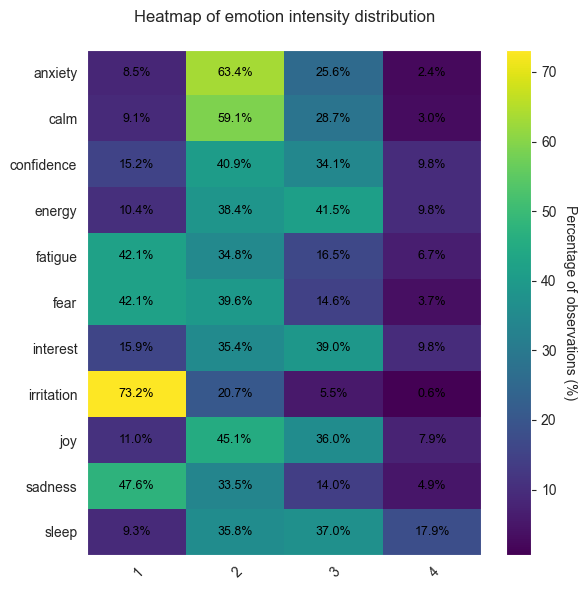

In [38]:
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(intensity_distribution_pct, cmap="viridis", aspect="auto")

ax.grid(False)
ax.set_xticks(range(len(intensity_distribution_pct.columns)))
ax.set_xticklabels(
    intensity_distribution_pct.columns, rotation=45, ha="right", rotation_mode="anchor"
)
ax.set_yticks(range(len(intensity_distribution_pct.index)))
ax.set_yticklabels(intensity_distribution_pct.index)

for i in range(len(intensity_distribution_pct.index)):
    for j in range(len(intensity_distribution_pct.columns)):
        ax.text(
            j,
            i,
            f"{intensity_distribution_pct.iloc[i, j]:.1f}%",
            ha="center",
            va="center",
            color="black",
            fontsize=9,
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Percentage of observations (%)", rotation=270, labelpad=15)

plt.title("Heatmap of emotion intensity distribution", pad=20)
plt.tight_layout()
plt.show()

#### **Key user observations:**

1. **Dominant state `irritation`:** There is a critical predominance of the score "1" (73.2%). This visually confirms the hypothesis that it is appropriate to transform this feature into a Boolean (0 - norm, 1 - presence of a stimulus).
2. **Duplication of `calm` and `anxiety`:** The heat map shows an almost identical distribution structure for these states (peaks of 59.1% and 63.4% at the score "2", respectively). This indicates that in the current dataset they describe the same dynamics.
3. **High value consolidation hypothesis:** The score "4" is extremely sparse for most emotions (except for sleep - 17.9%). Combining the categories "3" and "4" can reduce the amount of noise and strengthen the signal for training the model.
4. **Negative group stability:** The visual pattern of `fatigue`, `sadness` and `fear` again shows similarities, especially in the distribution of low and medium intensity values.
5. **"Confidence Zone" (Score 2):** For positive states (`joy`, `confidence`, `interest`, `energy`), score 2 is the most frequent (35-45%). This is the "baseline performance level" or "normal day". The values of "3" in these columns are significant drivers for increasing the overall Score.
6. **Asymmetry of `sadness`:** Sadness has the highest percentage of units (47.6%) among the negative triad. This means that mild fatigue or fear is experienced more often than minimal sadness. The appearance of even a "2" in `sadness` is a much stronger negative marker for the model than a "2" in `fatigue`.
7. **"Smooth controllers" (`energy` / `interest`):** These features have the least contrast transitions between scores 2 and 3. They work as analog state controllers, unlike "discrete switches" like irritation or anxiety.

#### **Model conclusions:**

* **Sparse Feature Handling:** Due to the low density of score "4" (except sleep), it is worth applying **Binning** (3+4) to stabilize the weights and prevent overfitting on rare outliers.
* **Feature Redundancy:** The high correlation of `calm` and `anxiety` profiles hints at the possibility of creating a synthetic feature "Emotional Tension" to avoid multicollinearity.
* **Binary Trigger for `irritation`:** It has been mathematically confirmed that irritation works as a "trigger". The model should treat any value > 1 as a strong anomalous signal that breaks the baseline.
* **Sleep as a dynamic predictor:** `sleep` has the most even color distribution. It carries the most entropy (information) and can be a key node in decision trees.
* **Sensitivity to negativity:** The model should have higher weights for rare states (e.g. `sadness >= 2`), because due to the high percentage of `1`s in these columns, any increase is a radical change in context.

## Executive Summary of Section 3: "The Emotional Constitution"

This section has transformed scattered subjective assessments into a structured mathematical model of the emotional state. We have identified not only how individual emotions influence mood but also the mechanics of internal cognitive filters used when selecting the final daily score.

### 1. Emotional Homeostasis and "Point Zero"
The central axis of the system is **Score 4**, which is mathematically confirmed as the "Absolute Zero."
* **"Calm" Status:** All Z-scores at this point fall within the noise zone ($<|0.2|$). Score 4 represents a state of emotional equilibrium where no single emotion dominates.
* **Balance as a Filter:** The synthetic feature `balance` (Pos - Neg) shows a clear peak in the 0-1 zone, confirming the system's tendency to return to homeostasis after any fluctuations.

### 2. Feature Hierarchy: Drivers vs. Noise
Based on the analysis of variability (STD), kurtosis, and variance, the "Elite" set of features has been identified:

| Category | Features | Role for ML Model |
| :--- | :--- | :--- |
| **Gold Standard** | `Joy`, `Energy`, `Sadness` | **Primary Features:** Highest Information Gain. `Joy` is the main linear driver; `Sadness` is the "catastrophe" marker. |
| **Dynamic Background**| `Fatigue`, `Interest`, `Sleep` | **Contextual Features:** Fatigue is the most volatile. Sleep is an inert factor with high entropy (ideal for a Root Node). |
| **Specific Triggers** | `Irritation`, `Fear` | **Binary Flags:** "Sniper" features. Activation ($>1$) indicates a 90% probability of a low Score. |
| **Statistical Noise** | `Anxiety`, `Calm`, `Confidence` | **Baseline Bias:** Anxiety is almost always present. These have low variability and require combination/encoding. |

### 3. The "Price" of Emotional Transitions (Delta Analysis)
The transition between scores is non-linear; each step has its own "code":
* **3 → 4 (Recovery):** Occurs through "dropping ballast" (reduction in fatigue and sadness) rather than an increase in positivity.
* **4 → 5 (Activation):** The entry point into productivity, driven by a "boost" in interest and energy.
* **5 → 6+ (Euphoria):** Pure dominance of joy, where `Joy` becomes an anomaly (Z-score $> 2.0$).

### 4. Target Synergy and Cognitive Biases
A comparison between the subjective log (`common_mood_log`) and the synthetic target revealed a "Rounding Down Effect":
* **The 4 vs. 5 Paradox:** The respondent tends to set a "safe 4" even when emotional markers (synthetic) point to a "5". A score of 4 often merely means the "absence of problems," while the actual high-resource state begins above this level.
* **Emotional "Veto":** `Irritation` and `Sadness` operate non-linearly. Even with high positive indicators, the appearance of these markers instantly collapses the subjective score.

### 5. Modeling Strategy (Action Plan)

**Feature Engineering:**
1.  **`Emotional_Encoding`:** Create a `Negativity_Release` feature (`Fatigue` + `Sadness`) to detect recovery from crisis states.
2.  **Binarization:** Convert `Irritation` into a 0/1 flag to stabilize the signal.
3.  **Asymmetry Handling:** Apply Log Transformation to negative emotions due to their "exponential" decay characteristic.

**Architecture Choice:**
Priority is given to **Decision Trees (XGBoost/Random Forest)**. They are better suited than linear models for handling sharp thresholds (Veto-logic) and the "flat" distributions of sleep, automatically identifying the transition points between "baseline calm" and "active resource."

---
**Verdict:** Section 3 confirms the high quality of the collected data. We have identified a "glass ceiling"

## 4. Comparative Distribution & Data Drift Analysis
### 4.1. Data Drift & Structural Consistency Analysis
This analysis focuses on comparing distributions across time periods to validate a "synthetic" target as a reliable proxy for the subjective log.

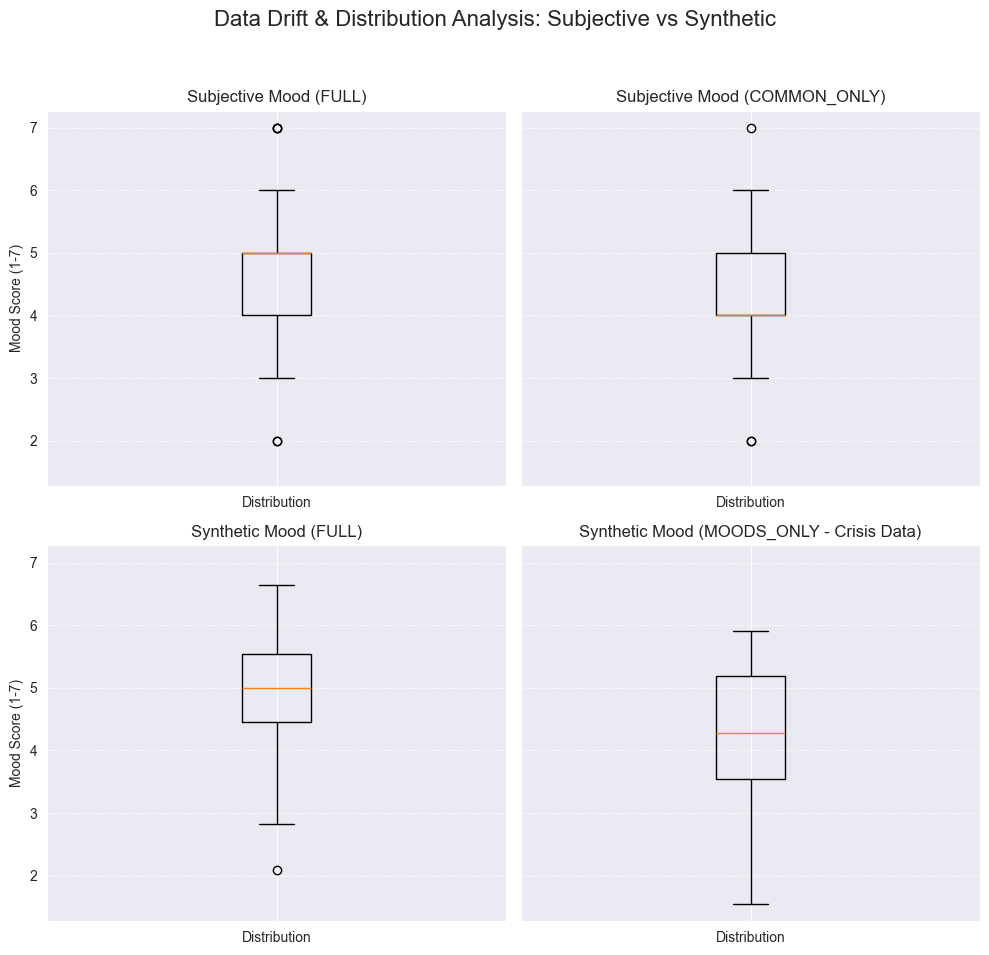

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=True)
fig.suptitle("Data Drift & Distribution Analysis: Subjective vs Synthetic", fontsize=16)


axes[0, 0].boxplot(dfs[DatasetPeriod.FULL]["common_mood_log"].dropna())
axes[0, 0].set_title("Subjective Mood (FULL)")
axes[0, 0].set_ylabel("Mood Score (1-7)")

axes[0, 1].boxplot(dfs[DatasetPeriod.COMMON_ONLY]["common_mood_log"].dropna())
axes[0, 1].set_title("Subjective Mood (COMMON_ONLY)")

axes[1, 0].boxplot(dfs[DatasetPeriod.FULL]["total_mood"].dropna())
axes[1, 0].set_title("Synthetic Mood (FULL)")
axes[1, 0].set_ylabel("Mood Score (1-7)")

axes[1, 1].boxplot(dfs[DatasetPeriod.MOODS_ONLY]["total_mood"].dropna())
axes[1, 1].set_title("Synthetic Mood (MOODS_ONLY - Crisis Data)")

for ax in axes.flat:
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.set_xticklabels(["Distribution"])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### 1. Comparative Bias Analysis
* **Subjective Log:** The median is consistently at **4.0**. The narrow interquartile range ($IQR$) indicates "cognitive conservation" - a persistent tendency of the respondent to avoid extreme assessments when directly logging (an attempt to seem "normal" or a psychological anchor at the average value).
* **Synthetic Mood:** Demonstrates a shift of the median up to **5.0** and a significant expansion of the upper "whisker". This supports the hypothesis that emotional decomposition reveals positive states that are often ignored or "rounded down" in the overall subjective assessment (the "Safe 4" effect).

#### 2. Detection of "Crisis Data" in the MOODS_ONLY Period
Analysis of the distribution of the synthetic indicator in the period of absence of direct logs revealed a unique data structure critical for training the ML model:
* **Negative Skew:** 50% of the data are in the range **3.5 – 5.1**, which is noticeably lower than other time intervals.
* **Long lower tail:** The lower whisker of the boxplot reaches **1.5**. This makes this subarray the only representative source of information about extremely low states of the system.
* **Verdict on representativeness:** Data from the `MOODS_ONLY` period are not statistical noise. On the contrary, they are the most valuable for training the model to recognize negative phases and critical mood dips.

#### 3. Statistical validation of the target

| Metric | Subjective (Full) | Synthetic (Full) | Synthetic (Moods Only) |
| :--- | :--- | :--- | :--- |
| **Median** | 4.0 | 5.0 | 4.3 |
| **Interquartile Range (IQR)** | 1.0 (4.0 to 5.0) | 1.1 (4.4 to 5.5) | 1.6 (3.5 to 5.1) |
| **Skewness** | Neutral | Up (Positive) | **Down (Crisis)** |

### 4.2. Deep Density Analysis (KDE Analysis)

In [40]:
from scipy.stats import gaussian_kde


def build_kpe_plot(data1, data2, data1_txt, data2_txt):
    density1 = gaussian_kde(data1)
    x1 = np.linspace(min(data1), max(data1), 1000)
    density2 = gaussian_kde(data2)
    x2 = np.linspace(min(data2), max(data2), 1000)

    fig, ax = plt.subplots(1, 2, figsize=(14, 7), sharey=True, sharex=True)

    for i, (data, x, density, title) in enumerate(
        [(data1, x1, density1, data1_txt), (data2, x2, density2, data2_txt)]
    ):
        ax[i].plot(x, density(x), color="#4285F4", lw=3, label="KDE Density")
        ax[i].fill_between(x, 0, density(x), color="#4285F4", alpha=0.2)

        ax[i].plot(
            data,
            np.full_like(data, -0.02),
            "|",
            color="white",
            alpha=0.5,
            markersize=10,
            label="Actual Logs",
        )

        mean_val = data.mean()
        median_val = data.median()

        ax[i].axvline(
            mean_val, color="#EA4335", linestyle="--", lw=2, label=f"Mean: {mean_val:.2f}"
        )
        ax[i].axvline(
            median_val, color="#FBBC05", linestyle="-", lw=2, label=f"Median: {median_val:.2f}"
        )

        q25, q75 = data.quantile(0.25), data.quantile(0.75)
        ax[i].axvspan(q25, q75, color="gray", alpha=0.1, label="IQR (Middle 50%)")

        ax[i].set_title(title, fontsize=14, fontweight="bold", pad=15)
        ax[i].set_xlabel("Mood Score", fontsize=12)
        ax[i].grid(alpha=0.2, linestyle="--")
        ax[i].legend(loc="upper left", fontsize=9)

    ax[0].set_ylabel("Density / Frequency", fontsize=12)
    plt.tight_layout()
    plt.show()

#### 4.2.1. Psychometric profile of the respondent: FULL PERIOD vs COMMON ONLY

A distribution density analysis (KDE) revealed key patterns in how the respondent assessed their own state with and without detailed emotional tracking.

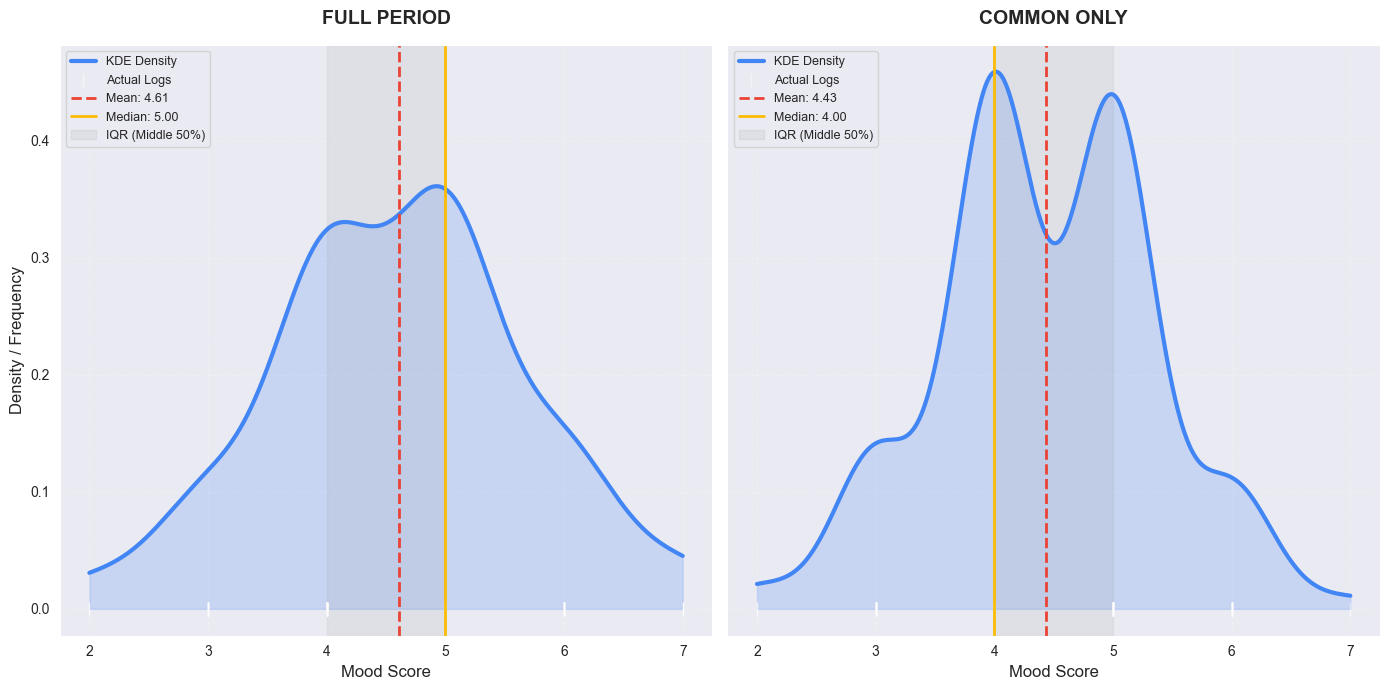

In [41]:
common_mood_log_full = dfs[DatasetPeriod.FULL]["common_mood_log"]
common_mood_log_common_only = dfs[DatasetPeriod.COMMON_ONLY]["common_mood_log"]

build_kpe_plot(common_mood_log_full, common_mood_log_common_only, "FULL PERIOD", "COMMON ONLY")

**Objective observations and insights:**

* **The 4.5 Gap:** Both graphs show a clear "sag" in the density in the **4.5** range. The respondent demonstrates bimodal thinking: the state is classified either as "basically stable" (**4.0**) or as "resourceful" (**5.0**), practically ignoring intermediate values.
* **Expansion of the emotional spectrum:** In the period with emotion tracking (`FULL PERIOD`), pronounced peaks appear in the area of ​​high scores (**6.0–7.0**), which were almost absent in the general logging period. This indicates that the decomposition into emotions allows the respondent to better identify states of elevation.
* **The "Safe 4" effect and median shift:** In the `COMMON ONLY` period, an anomalous concentration of values ​​around the **4.0** score (median) is observed. Without emotional context, the respondent tends to simplify their state to the "norm", while in the `FULL PERIOD` the median shifts to **5.0**, indicating a more nuanced perception of positive states.
* **Stability of critical points:** The value **2.0** (deep negativity) occurs with the same low frequency in both periods, indicating the stability of the identification of critical states regardless of the logging method.

**Value for the ML model:**

1. **Nonlinearity of transitions:** The model must take into account that the transition **4 → 5** is not just a linear step, but a qualitative change in state (overcoming the "4.5 threshold").
2. **Resource detection:** The appearance of 6 and 7 points in the new period gives the model the necessary data to train a predictor of "peak productivity" based on emotional features.
3. **Bias Correction:** The analysis confirms the need to calibrate the model, taking into account the fact that the score "5" in the current period is more informative than in the previous one.

### 4.2.2. Analysis of the synthetic indicator (Total Mood): FULL vs MOODS ONLY

This stage of the analysis focuses on the validation of the "mathematical mood" derived from the 8 basic emotions. We compare the stable period (`FULL`) with the period of no direct logs (`MOODS ONLY`) to understand the limits of the synthetic target.

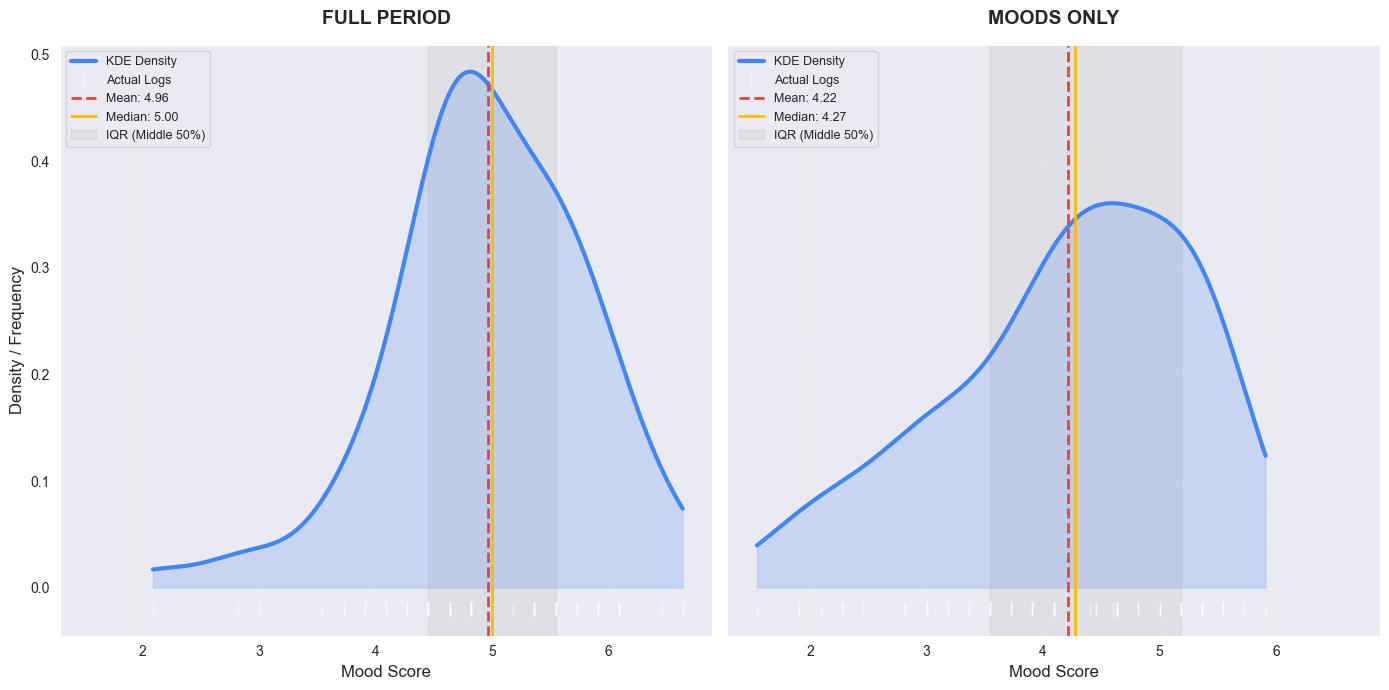

In [42]:
total_mood_full = dfs[DatasetPeriod.FULL]["total_mood"]
total_mood_moods_only = dfs[DatasetPeriod.MOODS_ONLY]["total_mood"]
build_kpe_plot(total_mood_full, total_mood_moods_only, "FULL PERIOD", "MOODS ONLY")

**Objective observations and respondent analysis:**

* **Calibration Shift:** There is a significant difference in medians: **5.0** in `FULL` versus **4.27** in `MOODS ONLY`.
* *Insight:* This confirms that the November-December period (`MOODS ONLY`) was objectively more depressive/difficult than the background state. The synthetic indicator successfully captured this shift, making it a valid tool for restoring missing labels.
* **Evolution from bimodality to smoothness:** In contrast to the "ragged" graph of subjective assessments (where there were clear humps at 4 and 5), the `total_mood` graph demonstrates a much smoother curve.
* *Insight:* Tracking emotions eliminates the respondent's "black and white" thinking. The mathematical sum of emotions creates a continuous spectrum of states, which is much better for training regression models.
* **Asymmetry of the "Crisis Tail":** In the `MOODS ONLY` period, the left tail (the area of ​​low values) is much thicker.
* *Insight:* During this period, the respondent was more often in states where the sum of negative emotions outweighed positive ones. This confirms the representativeness of the period as a "stress test" for the model.
* **Convergence of means (Synthetic Match):** The mean value of 4.22 (`MOODS ONLY`) and 4.96 (`FULL`) correlates with visual observations of boxplots. The system is stable: synthetics do not create anomalous emissions that would not exist in reality.

**Value for ML model:**

1. **High resolution:** Using `total_mood` as a proxy target instead of discrete scores 1-7 gives the model more information about "micro-fluctuations" of mood.
2. **Training on low amplitudes:** Due to the fact that in `MOODS ONLY` the distribution is shifted to the left, the model will receive enough examples of "bad days" to correctly calculate the weights of negative emotions.
3. **Overcoming psychological filters:** The synthetic indicator ignores the cognitive desire of the respondent to seem "normal" (put 4), capturing the real emotional balance.

### 4.3. General conclusion on section 4: Distribution analysis and Data Drift

Section 4 confirmed that changing the logging modes significantly affected the statistical structure of the data, but did not violate their integrity.

* **Validation of the `MOODS_ONLY` period:** The analysis proved that this period is a unique “stress test”. It contains the lowest mood indicators (up to 1.5 points), which are absent in other periods. This makes it critically important for the model to learn to recognize depressive or crisis states.
* **Detecting cognitive filters:** A comparison of KDE graphs showed that subjective logging has a “hole” at the **4.5** mark. The respondent is prone to binary evaluation (either 4 — “ok” or 5 — “good”). The synthetic indicator successfully fills this gap, making the target continuous and smooth.
* **Calibration Shift:** Emotion tracking shifted the median up (from **4.0** to **5.0**). This is not just an “improvement in mood”, but an increase in perceptual resolution: the respondent began to notice positive states (6 and 7 points), which were previously ignored in the general log.
* **Verdict:** Data from different periods should be combined. The detected "drift" is not an error, but a consequence of deeper introspection, which the model should take into account through calibration of the weights.

# General Conclusion: EDA 2 Strategy & Insights

**Executive Summary:**
The second stage of analysis transformed subjective diary entries into a validated dataset for ML. We confirmed that the synthetic target (based on emotions) is more relevant than direct ratings, as it ignores the cognitive biases of the respondent and has higher resolution.

### 1. Validation and Target Selection
* **Synthetic vs Log:** Correlation **0.74** confirms that the mathematical model of mood corresponds to reality.
* **Advantage:** The synthetic target is continuous (float), which eliminates the "rounding bias" and allows the model to see smooth transitions between states.
* **Solution:** Use both targets for comparative training, but give priority to the synthetic one for predicting the "hidden" emotional background.

### 2. Feature Engineering
* **Hierarchy:** `Joy` and `Energy` are identified as the main drivers, and `Sadness` and `Irritation` are identified as critical markers of decline.
* **Veto Logic:** A nonlinear dependence is identified - the appearance of irritation or fear "collapses" the subjective assessment regardless of the level of positive emotions.
* **New Features:** Implementation of `Negativity_Load` (Fatigue + Sadness) and lag features (`Lag_1`, `Rolling_Mean`) to take into account emotional inertia.

### 3. Data Modes and Data Drift
* **Stress Test:** The `MOODS_ONLY` period is recognized as the most valuable for training the model on low mood amplitudes (1.5 – 3.0), since it contains unique "crisis" data.
* **Calibration:** The model should take into account the shift of the median from **4.0** to **5.0**, which arose due to the increase in the resolution of the respondent's perception.

### 4. Training Strategy: "The Teacher-Student Pipeline"
To overcome the problem of missing labels in the `MOODS_ONLY` period and avoid Data Leakage, a three-stage approach was chosen:

1. **Stage 1 (Teacher):** Training the decoder model on the `FULL` period (Emotions $T \rightarrow$ Log $T$) to learn the subjective filters of the respondent.
2. **Stage 2 (Reconstruction):** Generation of **Pseudo-labels** for the `MOODS_ONLY` period. This allows you to obtain a continuous time series without losing data for November-December.
3. **Stage 3 (Forecasting):** Training the final autoregressive model (Emotions $T-1$, Sleep $T \rightarrow$ Mood $T$).
4. **Validation:** The final accuracy assessment is carried out **exclusively** on real labels of the `FULL` period.

### 5. Technical modeling stack
* **Algorithm:** Priority — **XGBoost / LightGBM**. Only gradient boosting on trees will be able to correctly process the "veto logic" and nonlinear thresholds (for example, a gap at the 4.5 mark).
* **Scaling:** `RobustScaler` to neutralize the impact of extreme emotional outliers.

**Verdict:** EDA 2 confirmed the high quality of the data and revealed hidden patterns of subjective perception. We move from descriptive analysis to building a predictive vector.